In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("../data/scholarship_data.csv")

df.head()

,CGPA,Attendance,Family_Income,Backlogs,Category,Semester,Sports,Extra_Activities,Scholarship
0,7.0,69,100000,5,SC,2,1,0,0
1,9.6,73,20000,0,BC,2,0,0,1
2,8.0,63,180000,0,OC,1,1,0,0
3,9.9,62,150000,1,ST,3,0,1,0
4,8.0,71,30000,4,BC,4,1,0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CGPA              1000 non-null   float64
 1   Attendance        1000 non-null   int64  
 2   Family_Income     1000 non-null   int64  
 3   Backlogs          1000 non-null   int64  
 4   Category          1000 non-null   str    
 5   Semester          1000 non-null   int64  
 6   Sports            1000 non-null   int64  
 7   Extra_Activities  1000 non-null   int64  
 8   Scholarship       1000 non-null   int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 72.4 KB


In [4]:
df.isnull().sum()

CGPA                0
Attendance          0
Family_Income       0
Backlogs            0
Category            0
Semester            0
Sports              0
Extra_Activities    0
Scholarship         0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.describe()

,CGPA,Attendance,Family_Income,Backlogs,Semester,Sports,Extra_Activities,Scholarship
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.713100,79.531000,122540.000000,2.402000,4.411000,0.513000,0.497000,0.337000
std,1.324369,11.911966,88252.687987,1.733609,2.285016,0.500081,0.500241,0.472921
min,5.500000,60.000000,20000.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,6.500000,69.000000,50000.000000,1.000000,2.000000,0.000000,0.000000,0.000000
50%,7.700000,79.000000,100000.000000,2.000000,4.000000,1.000000,0.000000,0.000000
75%,8.825000,90.000000,180000.000000,4.000000,6.000000,1.000000,1.000000,1.000000
max,10.000000,100.000000,300000.000000,5.000000,8.000000,1.000000,1.000000,1.000000


In [8]:
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()

df["Category"] = category_encoder.fit_transform(df["Category"])

In [9]:
X = df.drop("Scholarship", axis=1)

y = df["Scholarship"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross Validation Accuracy:
0.925


In [25]:
model = grid.best_estimator_

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [26]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.92


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       133
           1       0.92      0.84      0.88        67

    accuracy                           0.92       200
   macro avg       0.92      0.90      0.91       200
weighted avg       0.92      0.92      0.92       200



In [29]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[128   5]
 [ 11  56]]


In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
0              CGPA    0.298715
2     Family_Income    0.211624
3          Backlogs    0.165561
1        Attendance    0.094967
7  Extra_Activities    0.071003
6            Sports    0.058230
5          Semester    0.054947
4          Category    0.044953


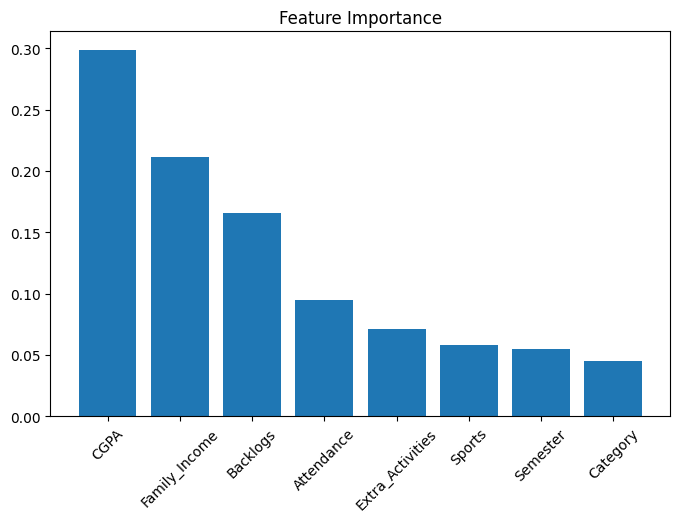

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [32]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.99875
Testing Accuracy  : 0.92


In [33]:
student = [[
    9.1,      # CGPA
    92,       # Attendance
    180000,   # Family Income
    0,        # Backlogs
    1,        # Category (encoded)
    5,        # Semester
    1,        # Sports
    1         # Extra Activities
]]

prediction = model.predict(student)

print("Prediction:", prediction[0])

Prediction: 1


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [34]:
if prediction[0] == 1:
    print("Eligible for Scholarship")
else:
    print("Not Eligible for Scholarship")

Eligible for Scholarship


In [35]:
probability = model.predict_proba(student)

print("Probability:", probability)

Probability: [[0.18983333 0.81016667]]


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [36]:
joblib.dump(model, "../models/scholarship_model.pkl")
joblib.dump(category_encoder, "../models/category_encoder.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
